In [1]:
# ================================
# Load Large Twitch Dataset (Custom Paths)
# ================================

import pandas as pd

# File paths (Windows paths with escaped backslashes)
edges_path = r"C:\Users\tuq24449\OneDrive - Temple University\Temple\2025\Spring '25\CIS 5524\Final Project\twitch_gamers\large_twitch_edges.csv"
features_path = r"C:\Users\tuq24449\OneDrive - Temple University\Temple\2025\Spring '25\CIS 5524\Final Project\twitch_gamers\large_twitch_features.csv"

# --- Load edges ---
try:
    edges = pd.read_csv(edges_path)
    print("✅ Edges loaded successfully.")
    print("📊 First 5 rows of edges (friendship links):")
    print(edges.head())
    print(f"🔗 Total number of edges: {len(edges)}\n")
except FileNotFoundError:
    print("❌ Could not find the edges file.")

# --- Load features ---
try:
    features_df = pd.read_csv(features_path, index_col=0)
    print("✅ Features loaded successfully.")
    print("📊 First 5 rows of features:")
    print(features_df.head())
    print(f"👤 Total number of users with features: {len(features_df)}\n")
except FileNotFoundError:
    print("❌ Could not find the features file.")

# --- Basic Info ---
print("🔍 Dataset Overview:")
print("Edge columns:", edges.columns.tolist())
print("Feature columns:", features_df.columns.tolist())


✅ Edges loaded successfully.
📊 First 5 rows of edges (friendship links):
   numeric_id_1  numeric_id_2
0         98343        141493
1         98343         58736
2         98343        140703
3         98343        151401
4         98343        157118
🔗 Total number of edges: 6797557

✅ Features loaded successfully.
📊 First 5 rows of features:
        mature  life_time  created_at  updated_at  numeric_id  dead_account  \
views                                                                         
7879         1        969  2016-02-16  2018-10-12           0             0   
500          0       2699  2011-05-19  2018-10-08           1             0   
382502       1       3149  2010-02-27  2018-10-12           2             0   
386          0       1344  2015-01-26  2018-10-01           3             0   
2486         0       1784  2013-11-22  2018-10-11           4             0   

       language  affiliate  
views                       
7879         EN          1  
500         

In [2]:
# Set of all user IDs from features
feature_ids = set(features_df['numeric_id'])

# Set of all user IDs in edges
edge_ids = set(edges['numeric_id_1']).union(set(edges['numeric_id_2']))

# Check overlap
missing_in_features = edge_ids - feature_ids
missing_in_edges = feature_ids - edge_ids

print(f"🔍 Users in edge list but missing from features: {len(missing_in_features)}")
print(f"🔍 Users in features but not in edge list: {len(missing_in_edges)}")


🔍 Users in edge list but missing from features: 0
🔍 Users in features but not in edge list: 0


In [3]:
import matplotlib.pyplot as plt
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


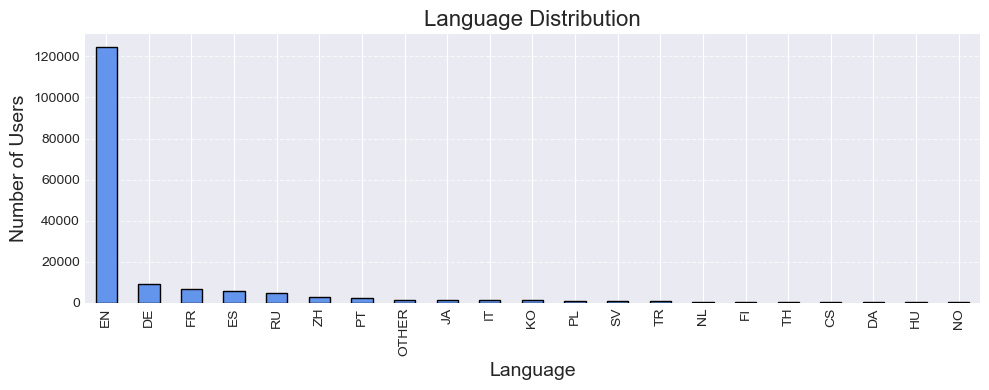

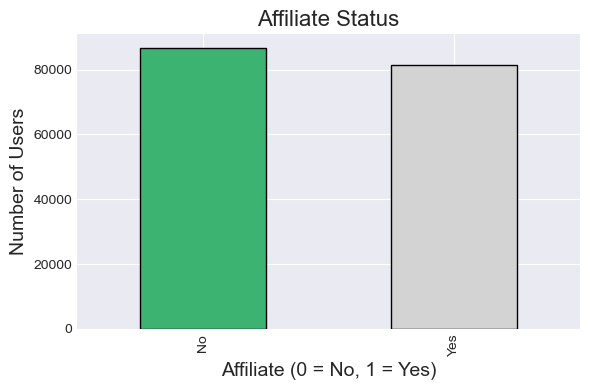

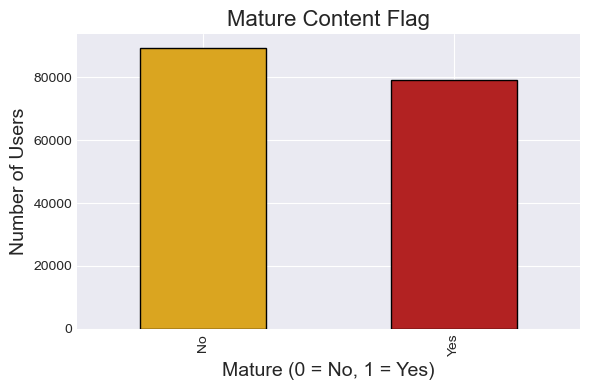

In [4]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')  # ✅ A valid and clean style

# Language distribution
features_df['language'].value_counts().plot(
    kind='bar', figsize=(10, 4), color='cornflowerblue', edgecolor='black'
)
plt.title("Language Distribution", fontsize=16)
plt.xlabel("Language", fontsize=14)
plt.ylabel("Number of Users", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Affiliate status distribution
features_df['affiliate'].value_counts().plot(
    kind='bar', figsize=(6, 4), color=['mediumseagreen', 'lightgray'], edgecolor='black'
)
plt.title("Affiliate Status", fontsize=16)
plt.xlabel("Affiliate (0 = No, 1 = Yes)", fontsize=14)
plt.ylabel("Number of Users", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.tight_layout()
plt.show()

# Mature content distribution
features_df['mature'].value_counts().plot(
    kind='bar', figsize=(6, 4), color=['goldenrod', 'firebrick'], edgecolor='black'
)
plt.title("Mature Content Flag", fontsize=16)
plt.xlabel("Mature (0 = No, 1 = Yes)", fontsize=14)
plt.ylabel("Number of Users", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.tight_layout()
plt.show()


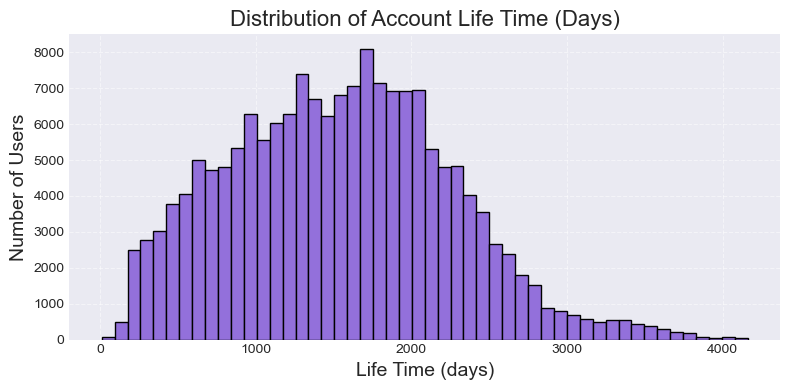

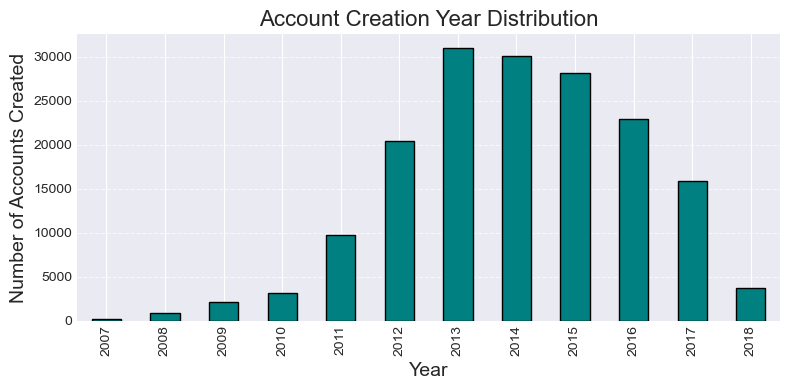

In [5]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')  # Set style globally

# 📊 Account life_time distribution
features_df['life_time'].plot(
    kind='hist', bins=50, figsize=(8, 4), color='mediumpurple', edgecolor='black'
)
plt.title("Distribution of Account Life Time (Days)", fontsize=16)
plt.xlabel("Life Time (days)", fontsize=14)
plt.ylabel("Number of Users", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 📆 Account creation year distribution
features_df['created_at'] = pd.to_datetime(features_df['created_at'])
creation_years = features_df['created_at'].dt.year.value_counts().sort_index()

creation_years.plot(
    kind='bar', figsize=(8, 4), color='teal', edgecolor='black'
)
plt.title("Account Creation Year Distribution", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Accounts Created", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [6]:
import random

# Use only the 'numeric_id' column as user IDs
user_ids = features_df['numeric_id'].tolist()
user_set = set(user_ids)

# Positive pairs = sampled edges from the graph
positive_pairs = list(edges.sample(10000).itertuples(index=False, name=None))

# Build a set of all real edges for quick lookup
existing_edges = set(map(tuple, map(sorted, edges.to_numpy())))

# Negative pairs = random pairs that are NOT friends
negative_pairs = set()
while len(negative_pairs) < 10000:
    u, v = random.sample(user_ids, 2)
    if (min(u, v), max(u, v)) not in existing_edges:
        negative_pairs.add((u, v))

negative_pairs = list(negative_pairs)


In [7]:
def extract_pair_features(u, v, features_df):
    u_data = features_df[features_df['numeric_id'] == u].squeeze()
    v_data = features_df[features_df['numeric_id'] == v].squeeze()

    # Extract values
    year_u = pd.to_datetime(u_data['created_at']).year
    year_v = pd.to_datetime(v_data['created_at']).year

    return {
        'same_language': int(u_data['language'] == v_data['language']),
        'same_affiliate': int(u_data['affiliate'] == v_data['affiliate']),
        'same_mature': int(u_data['mature'] == v_data['mature']),
        'life_time_diff': abs(u_data['life_time'] - v_data['life_time']),
        'avg_life_time': (u_data['life_time'] + v_data['life_time']) / 2,
        'creation_year_diff': abs(year_u - year_v),
        'is_same_year_created': int(year_u == year_v),
        'language_combo': f"{u_data['language']}-{v_data['language']}",
    }


In [8]:
import pandas as pd

feature_rows = []

# Positive samples
for u, v in positive_pairs:
    row = extract_pair_features(u, v, features_df)
    row['label'] = 1
    feature_rows.append(row)

# Negative samples
for u, v in negative_pairs:
    row = extract_pair_features(u, v, features_df)
    row['label'] = 0
    feature_rows.append(row)

# Convert to DataFrame
pair_df = pd.DataFrame(feature_rows)
print(pair_df.head())


   same_language  same_affiliate  same_mature  life_time_diff  avg_life_time  \
0              1               1            0            1283         2658.5   
1              1               0            1            1171         1773.5   
2              1               1            1              29         1954.5   
3              1               1            1            1878         2437.0   
4              1               1            1             302         1384.0   

   creation_year_diff  is_same_year_created language_combo  label  
0                   4                     0          EN-EN      1  
1                   3                     0          EN-EN      1  
2                   0                     1          EN-EN      1  
3                   5                     0          EN-EN      1  
4                   1                     0          EN-EN      1  


language_combo
CS-CS       1.0
FI-FI       1.0
TR-TR       1.0
TR-OTHER    1.0
CS-HU       1.0
TR-DE       1.0
TH-TH       1.0
SV-SV       1.0
PL-PL       1.0
NO-SV       1.0
Name: label, dtype: float64


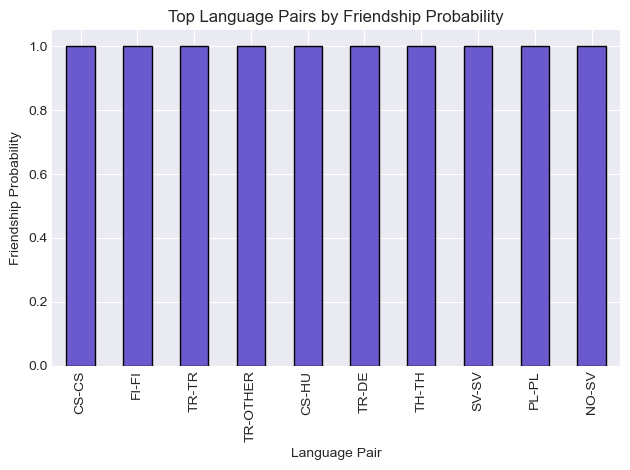

In [9]:
combo_stats = pair_df.groupby('language_combo')['label'].mean().sort_values(ascending=False)
print(combo_stats.head(10))

# Or visualize top combos
combo_stats.head(10).plot(kind='bar', color='slateblue', edgecolor='black')
plt.title("Top Language Pairs by Friendship Probability")
plt.xlabel("Language Pair")
plt.ylabel("Friendship Probability")
plt.tight_layout()
plt.show()


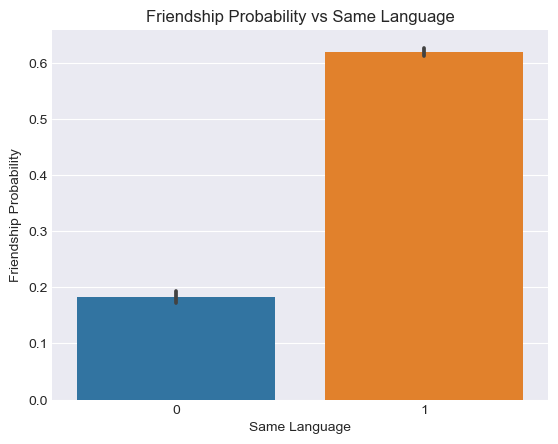

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


# Example: Does same_language increase chance of friendship?
sns.barplot(x='same_language', y='label', data=pair_df)
plt.title("Friendship Probability vs Same Language")
plt.xlabel("Same Language")
plt.ylabel("Friendship Probability")
plt.show()


In [11]:
import networkx as nx

# Create an undirected graph from edge list
G = nx.from_pandas_edgelist(edges, source='numeric_id_1', target='numeric_id_2')
print(f"✅ Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")


✅ Graph created with 168114 nodes and 6797557 edges


In [12]:
def extract_graph_features(u, v, G):
    # Make sure both nodes exist in the graph
    if not G.has_node(u) or not G.has_node(v):
        return {
            'num_common_neighbors': 0,
            'preferential_attachment': 0,
            'jaccard_similarity': 0,
            'adamic_adar': 0,
        }

    # Common neighbors
    common_neighbors = len(list(nx.common_neighbors(G, u, v)))

    # Preferential Attachment
    degree_product = G.degree(u) * G.degree(v)

    # Jaccard Similarity
    try:
        jaccard = list(nx.jaccard_coefficient(G, [(u, v)]))[0][2]
    except:
        jaccard = 0

    # Adamic-Adar Index
    try:
        adamic_adar = list(nx.adamic_adar_index(G, [(u, v)]))[0][2]
    except:
        adamic_adar = 0

    return {
        'num_common_neighbors': common_neighbors,
        'preferential_attachment': degree_product,
        'jaccard_similarity': jaccard,
        'adamic_adar': adamic_adar,
    }


In [13]:
full_feature_rows = []

for u, v in positive_pairs:
    row = extract_pair_features(u, v, features_df)
    row.update(extract_graph_features(u, v, G))
    row['label'] = 1
    full_feature_rows.append(row)

for u, v in negative_pairs:
    row = extract_pair_features(u, v, features_df)
    row.update(extract_graph_features(u, v, G))
    row['label'] = 0
    full_feature_rows.append(row)

full_pair_df = pd.DataFrame(full_feature_rows)
print(full_pair_df.head())


   same_language  same_affiliate  same_mature  life_time_diff  avg_life_time  \
0              1               1            0            1283         2658.5   
1              1               0            1            1171         1773.5   
2              1               1            1              29         1954.5   
3              1               1            1            1878         2437.0   
4              1               1            1             302         1384.0   

   creation_year_diff  is_same_year_created language_combo  \
0                   4                     0          EN-EN   
1                   3                     0          EN-EN   
2                   0                     1          EN-EN   
3                   5                     0          EN-EN   
4                   1                     0          EN-EN   

   num_common_neighbors  preferential_attachment  jaccard_similarity  \
0                     9                    11040            0.043062   
1 

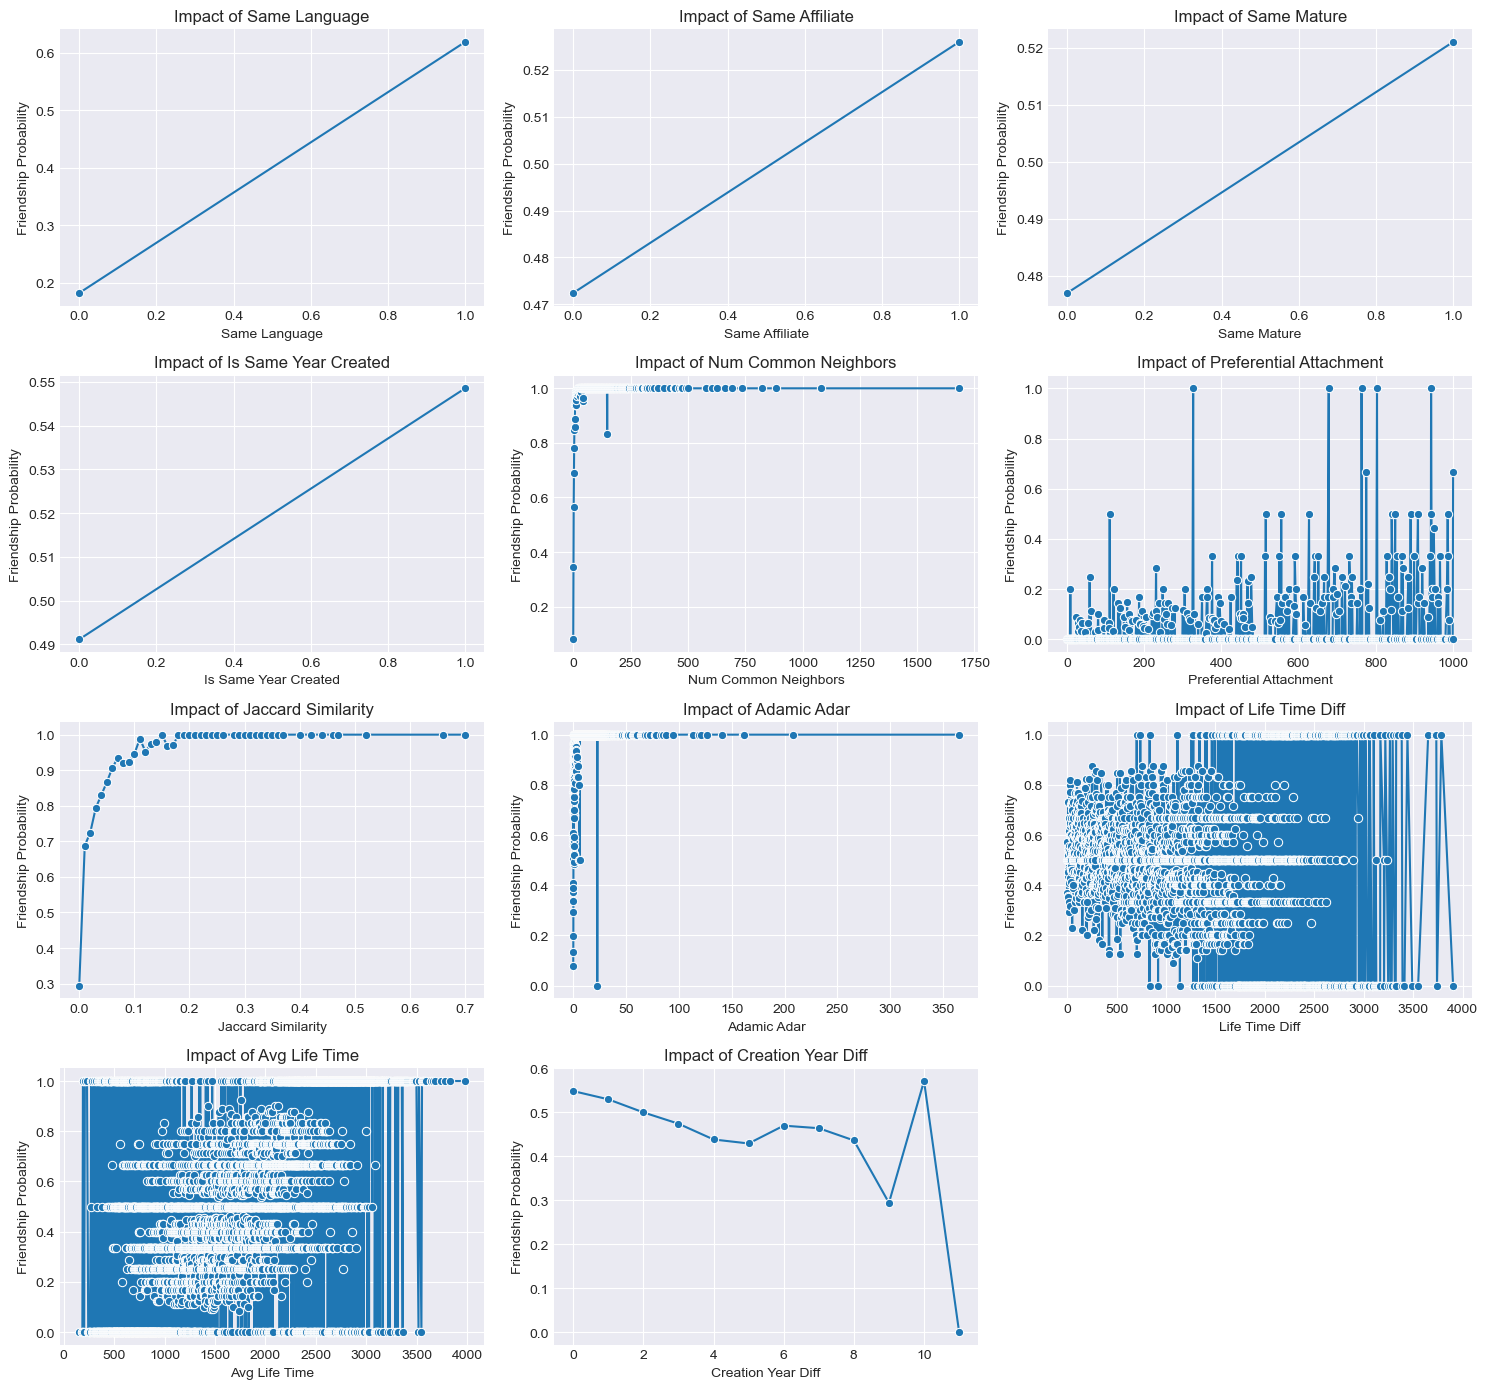

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Select features to analyze
features_to_plot = [
    'same_language', 'same_affiliate', 'same_mature',
    'is_same_year_created', 'num_common_neighbors',
    'preferential_attachment', 'jaccard_similarity', 'adamic_adar',
    'life_time_diff', 'avg_life_time', 'creation_year_diff'
]

# Round continuous features for grouping clarity
full_pair_df['jaccard_similarity_round'] = full_pair_df['jaccard_similarity'].round(2)
full_pair_df['adamic_adar_round'] = full_pair_df['adamic_adar'].round(2)
full_pair_df['preferential_attachment_round'] = full_pair_df['preferential_attachment'].clip(upper=1000)

# Replace originals with rounded versions for plotting
plot_map = {
    'preferential_attachment': 'preferential_attachment_round',
    'jaccard_similarity': 'jaccard_similarity_round',
    'adamic_adar': 'adamic_adar_round'
}

# Set up the plot grid
n = len(features_to_plot)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(cols * 5, rows * 3.5))

for i, feat in enumerate(features_to_plot):
    ax = plt.subplot(rows, cols, i + 1)
    
    # Use rounded feature if needed
    plot_feat = plot_map.get(feat, feat)

    # Aggregate
    agg = full_pair_df.groupby(plot_feat)['label'].mean().reset_index()

    # Plot
    sns.lineplot(x=plot_feat, y='label', data=agg, marker='o', ax=ax)
    ax.set_title(f"Impact of {feat.replace('_', ' ').title()}")
    ax.set_xlabel(feat.replace('_', ' ').title())
    ax.set_ylabel("Friendship Probability")

plt.tight_layout()
plt.show()


In [15]:
from sklearn.model_selection import train_test_split

# Separate features and labels
non_graph_features = pair_df.drop(columns=['language_combo', 'label'])
graph_features = full_pair_df.drop(columns=['language_combo', 'label'])

labels = pair_df['label']  # Same labels for both

# Train-test split
X1_train, X1_test, y1_train, y1_test = train_test_split(non_graph_features, labels, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(graph_features, labels, test_size=0.2, random_state=42)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Non-graph features model
clf1 = RandomForestClassifier(random_state=42)
clf1.fit(X1_train, y1_train)
y1_pred = clf1.predict(X1_test)
y1_proba = clf1.predict_proba(X1_test)[:, 1]

# Graph-enhanced model
clf2 = RandomForestClassifier(random_state=42)
clf2.fit(X2_train, y2_train)
y2_pred = clf2.predict(X2_test)
y2_proba = clf2.predict_proba(X2_test)[:, 1]


In [17]:
print("📌 Without Graph Features")
print(classification_report(y1_test, y1_pred))
print("AUC:", roc_auc_score(y1_test, y1_proba))

print("\n📌 With Graph Features")
print(classification_report(y2_test, y2_pred))
print("AUC:", roc_auc_score(y2_test, y2_proba))


📌 Without Graph Features
              precision    recall  f1-score   support

           0       0.67      0.66      0.66      1981
           1       0.67      0.68      0.67      2019

    accuracy                           0.67      4000
   macro avg       0.67      0.67      0.67      4000
weighted avg       0.67      0.67      0.67      4000

AUC: 0.724414628420215

📌 With Graph Features
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1981
           1       0.93      0.91      0.92      2019

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weighted avg       0.92      0.92      0.92      4000

AUC: 0.9673255511309895


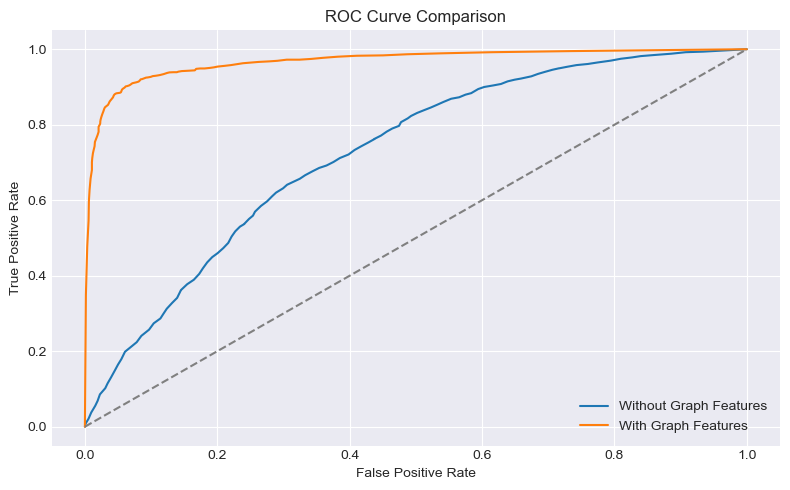

In [18]:
from sklearn.metrics import roc_curve

fpr1, tpr1, _ = roc_curve(y1_test, y1_proba)
fpr2, tpr2, _ = roc_curve(y2_test, y2_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr1, tpr1, label='Without Graph Features')
plt.plot(fpr2, tpr2, label='With Graph Features')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


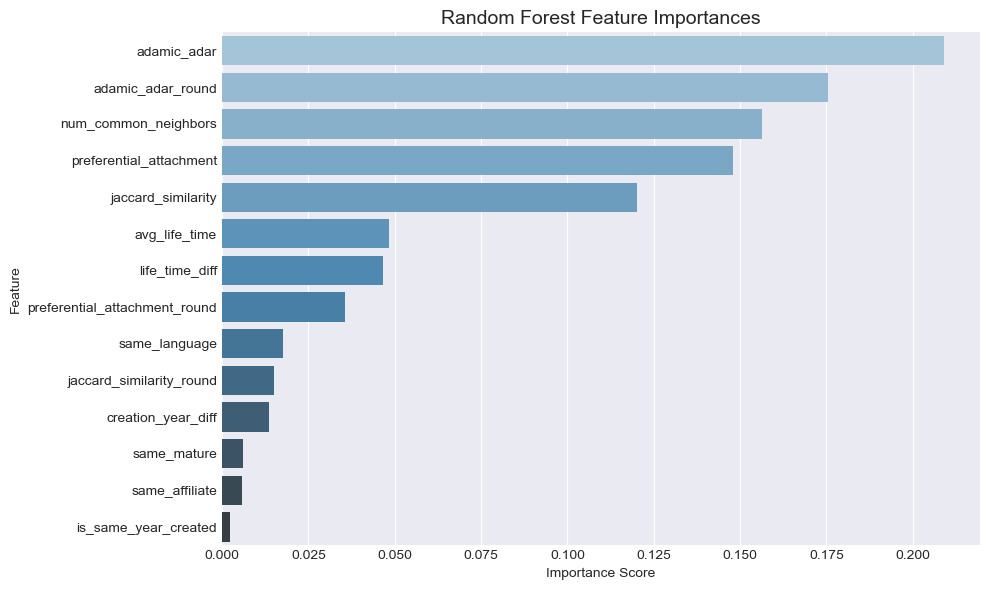

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np

# Drop non-numeric features
X = full_pair_df.drop(columns=['label', 'language_combo'])
y = full_pair_df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
sorted_indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_indices], y=np.array(feature_names)[sorted_indices], palette="Blues_d")
plt.title("Random Forest Feature Importances", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


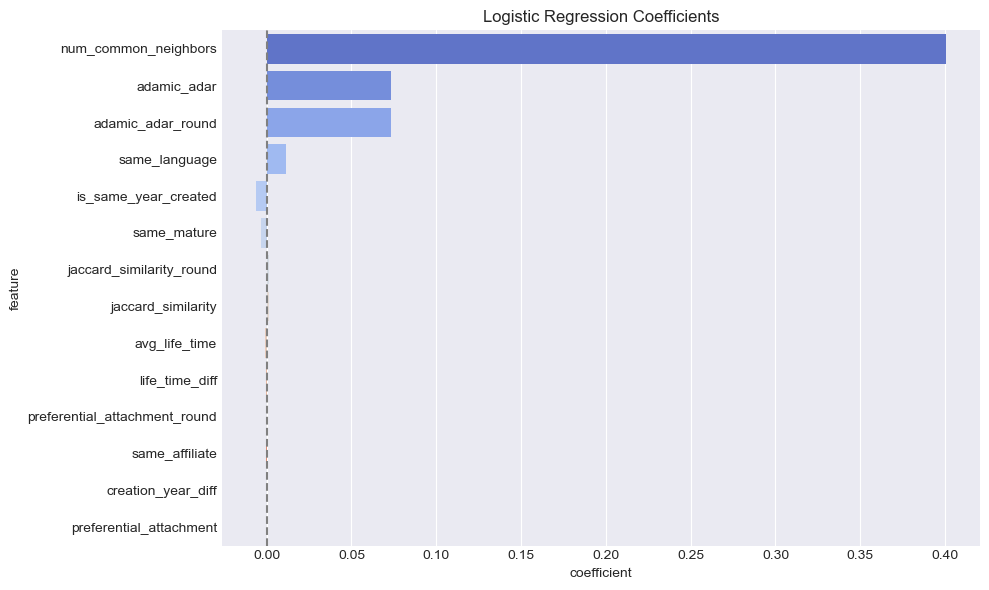

In [20]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression (scale-independent)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

coefs = lr_model.coef_[0]
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': coefs
}).sort_values(by='coefficient', key=abs, ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')
plt.title("Logistic Regression Coefficients")
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()


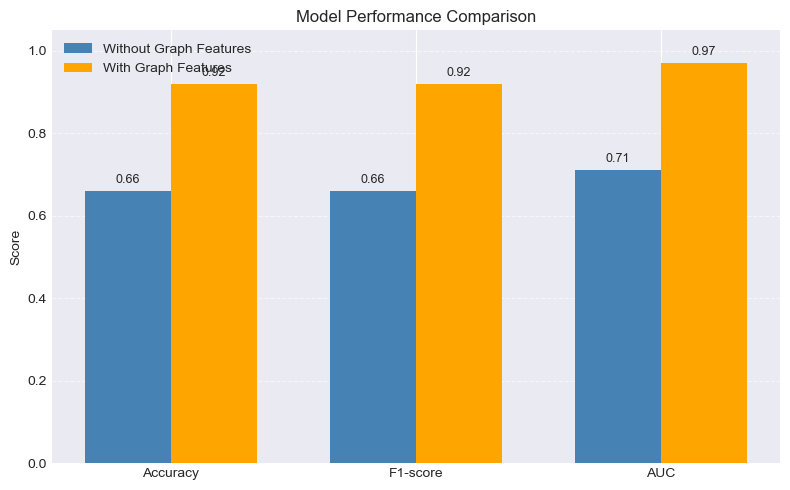

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = ['Accuracy', 'F1-score', 'AUC']
without_graph = [0.66, 0.66, 0.71]
with_graph = [0.92, 0.92, 0.97]

# Bar setup
x = np.arange(len(metrics))
width = 0.35

# Plotting
plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, without_graph, width, label='Without Graph Features', color='steelblue')
bars2 = plt.bar(x + width/2, with_graph, width, label='With Graph Features', color='orange')

# Labeling
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(x, metrics)
plt.title('Model Performance Comparison')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bars
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# Prepare train/test splits
X1 = pair_df.drop(columns=['language_combo', 'label'])
X2 = full_pair_df.drop(columns=['language_combo', 'label'])
y = pair_df['label']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

# Models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'SVM': SVC(probability=True)
}

# Evaluate each model
for model_name, model in models.items():
    print(f"\n📌 {model_name} — Without Graph Features")
    model.fit(X1_train, y1_train)
    y1_pred = model.predict(X1_test)
    y1_proba = model.predict_proba(X1_test)[:, 1]
    print(classification_report(y1_test, y1_pred))
    print("AUC:", roc_auc_score(y1_test, y1_proba))

    print(f"\n📌 {model_name} — With Graph Features")
    model.fit(X2_train, y2_train)
    y2_pred = model.predict(X2_test)
    y2_proba = model.predict_proba(X2_test)[:, 1]
    print(classification_report(y2_test, y2_pred))
    print("AUC:", roc_auc_score(y2_test, y2_proba))



📌 Logistic Regression — Without Graph Features
              precision    recall  f1-score   support

           0       0.71      0.64      0.67      1981
           1       0.68      0.75      0.71      2019

    accuracy                           0.69      4000
   macro avg       0.70      0.69      0.69      4000
weighted avg       0.70      0.69      0.69      4000

AUC: 0.7671424846092361

📌 Logistic Regression — With Graph Features
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1981
           1       0.93      0.83      0.88      2019

    accuracy                           0.88      4000
   macro avg       0.89      0.89      0.88      4000
weighted avg       0.89      0.88      0.88      4000

AUC: 0.9351026430135321

📌 XGBoost — Without Graph Features


C:\Users\tuq24449\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:41:49] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.72      0.63      0.67      1981
           1       0.67      0.76      0.71      2019

    accuracy                           0.69      4000
   macro avg       0.69      0.69      0.69      4000
weighted avg       0.69      0.69      0.69      4000

AUC: 0.7535990123108611

📌 XGBoost — With Graph Features


C:\Users\tuq24449\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:41:49] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1981
           1       0.93      0.90      0.92      2019

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weighted avg       0.92      0.92      0.92      4000

AUC: 0.9688021843971418

📌 SVM — Without Graph Features
              precision    recall  f1-score   support

           0       0.62      0.66      0.64      1981
           1       0.64      0.60      0.62      2019

    accuracy                           0.63      4000
   macro avg       0.63      0.63      0.63      4000
weighted avg       0.63      0.63      0.63      4000

AUC: 0.6800213719288166

📌 SVM — With Graph Features
              precision    recall  f1-score   support

           0       0.73      0.97      0.84      1981
           1       0.96      0.66      0.78      2019

    accuracy                           0.81      4000
   macro avg       

In [ ]:
# Step 1: Sort nodes by degree
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10000]  # top 20k nodes
top_node_ids = [node for node, _ in top_nodes]

# Step 2: Create subgraph from those nodes
G_sub = G.subgraph(top_node_ids).copy()

# Step 3: Run Node2Vec on this subgraph
node2vec = Node2Vec(
    G_sub, dimensions=64, walk_length=10, num_walks=20, workers=2
)
n2v_model = node2vec.fit(window=5, min_count=1, batch_words=4)


Computing transition probabilities:   0%|          | 0/10000 [00:00<?, ?it/s]

Create Embedding-Based Pair Features

In [52]:
import numpy as np

# Function to get Hadamard product of embeddings
def get_embedding_pair(u, v, model):
    try:
        emb_u = model.wv[str(u)]
        emb_v = model.wv[str(v)]
        return emb_u * emb_v  # Hadamard product
    except KeyError:
        return np.zeros(model.vector_size)  # If node not found


Build Dataset for Classifier

In [54]:
X_embed = []
y_embed = []

# Positive samples
for u, v in positive_pairs:
    X_embed.append(get_embedding_pair(u, v, n2v_model))
    y_embed.append(1)

# Negative samples
for u, v in negative_pairs:
    X_embed.append(get_embedding_pair(u, v, n2v_model))
    y_embed.append(0)

X_embed = np.array(X_embed)
y_embed = np.array(y_embed)


NameError: name 'n2v_model' is not defined

Train & Evaluate Classifier (Random Forest Example)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_embed, y_embed, test_size=0.2, random_state=42)

# Train model
clf_n2v = RandomForestClassifier(random_state=42)
clf_n2v.fit(X_train, y_train)

# Predictions
y_pred = clf_n2v.predict(X_test)
y_proba = clf_n2v.predict_proba(X_test)[:, 1]

# Evaluation
print("📌 Node2Vec Embedding-Based Model")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
